In [7]:
import numpy as np

import matplotlib.pyplot as plt
#%matplotlib inline

#import matplotlib.image as img
#import PIL.Image as Image 
from PIL import Image
import math
import cmath

import time

import csv

from numpy import binary_repr

from math import gcd

In [97]:
def computeKirsch(imge):
    """Computes and applies Kirsch operator to a given image."""
    N = imge.shape[0]
    result = np.zeros([N, N], dtype=float)
    
    #Copy the first and last rows, first and last columns
    result[0, :] = imge[0, :]
    result[:, 0] = imge[:, 0]
    result[N-1, :] = imge[N-1, :]
    result[:, N-1] = imge[:, N-1]
    
    #Kirsch Operator to the image.
    for i in np.arange(1, N-1):
        for j in np.arange(1, N-1):
            
            #Take the sub image.
            subImge = imge[i-1:i+2, j-1:j+2]
            
            #Number of elements in which Kirsch operator is applied
            n = 8
            
            #Flatten the sub image.
            subImgeFl = np.zeros(n, dtype=int)
            subImgeFl[:3] = subImge[0,:]
            subImgeFl[3] = subImge[1, -1]
            subImgeFl[4:7] = subImge[-1,:][::-1]
            subImgeFl[7] = subImge[1,0]

            #Variable that stores the maximum value
            mx = 1
            for k in np.arange(n):
                S = subImgeFl[k%n]+subImgeFl[(k+1)%n]+subImgeFl[(k+2)%n]
                T = (subImgeFl[(k+3)%n]+subImgeFl[(k+4)%n]+subImgeFl[(k+5)%n]+
                     subImgeFl[(k+6)%n]+subImgeFl[(k+7)%n])
                diff = abs((5*S)-(3*T)) 
                if diff > mx:
                    mx = diff
            result[i, j] = mx
            
    return result

In [98]:
def generateRowColumnSobelGradients():
    """Generates the x-component and y-component of Sobel operators."""
    rowGradient = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    colGradient = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    return rowGradient, colGradient

In [99]:
def computeSobel(imge):
    """Computes and applies Sobel operator to an image."""
    N = imge.shape[0]
    result = np.zeros([N, N], dtype=float)
    
    #Copy the first and last rows, first and last columns
    result[0, :] = imge[0, :]
    result[:, 0] = imge[:, 0]
    result[N-1, :] = imge[N-1, :]
    result[:, N-1] = imge[:, N-1]
    
    #Generate the Row and Column Gradients of Sober.
    rowGradient, colGradient = generateRowColumnSobelGradients()
    
    #Sober Operator to the image.
    for i in np.arange(1, N-1):
        for j in np.arange(1, N-1):
            subImge = imge[i-1:i+2, j-1:j+2]
            rowSum = np.sum(rowGradient * subImge)
            colSum = np.sum(colGradient * subImge)
            result[i, j] = math.sqrt(rowSum**2 + colSum**2)
    
    return result

Applying the operators

In [100]:
image = Image.open('Screenshot 2024-11-20 184405.png') # open an image
# imgeWoman = imgeWoman.convert(mode='L')

# imgeCameraman = Image.open("Images/lena_gray_256.tif") # open an image

In [35]:
img2 = np.array(image)

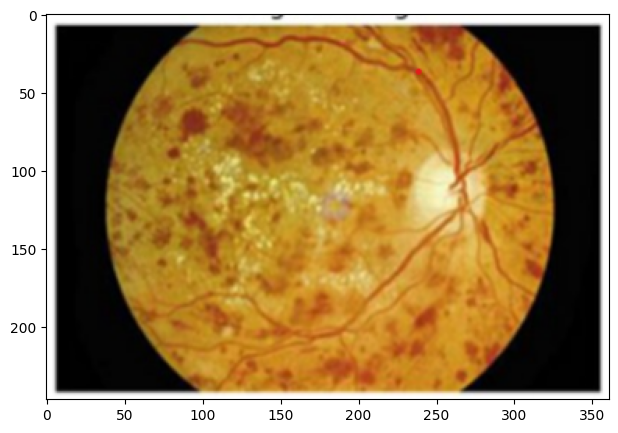

In [101]:
# fig, ax = plt.subplots(figsize=[5,5])
# fig[0].imshow(imge, cmap=plt.get_cmap('gray'))
plt.figure(figsize=[12,5])
plt.imshow(img2.squeeze(), cmap = "gray")

In [42]:
import cv2 as cv

In [51]:
import numpy as np

def histEq(img):
    hist,bins = np.histogram(img.flatten(),256,[0,256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf.max()
    
    plt.plot(cdf_normalized, color = 'b')
    plt.hist(img.flatten(),256,[0,256], color = 'r')
    plt.xlim([0,256])
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()

    cdf_m = np.ma.masked_equal(cdf,0)
    cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
    cdf = np.ma.filled(cdf_m,0).astype('uint8')
    plt.figure(figsize = (12, 5))
    # plt.imshow(cdf[img], cv.COLOR_BGR2RGB)
    plt.imshow(cv.cvtColor(cdf[img], cv.COLOR_BGR2RGB))
    plt.show()
    print("\n\n\n\n")

    
    plt.plot(cdf, color = 'b')
    plt.hist(img.flatten(),256,[0,256], color = 'r')
    plt.xlim([0,256])
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()    
    img2 = cdf[img]
    plt.imshow(img2)

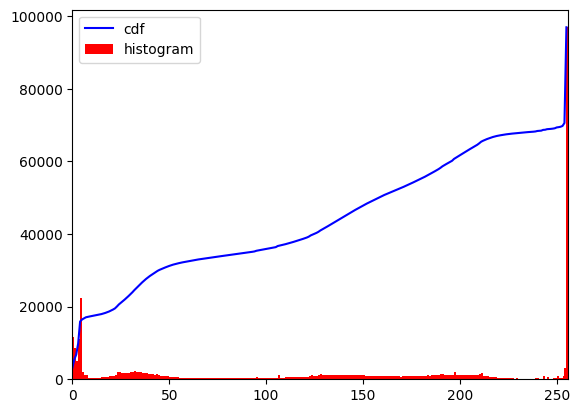

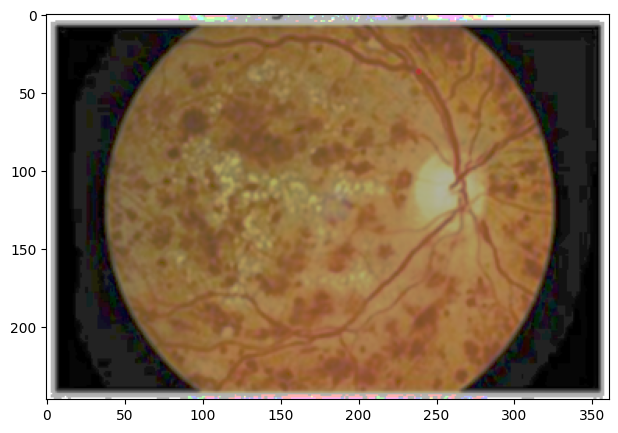





this is new picture


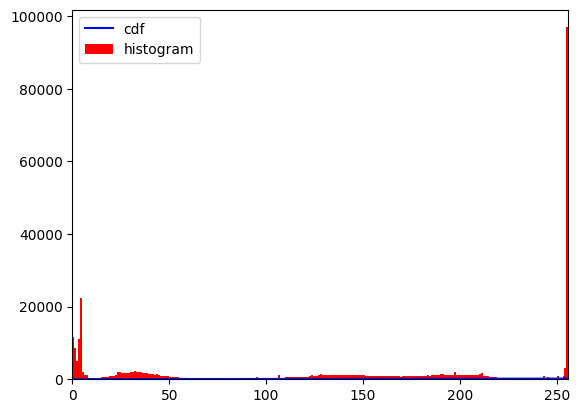

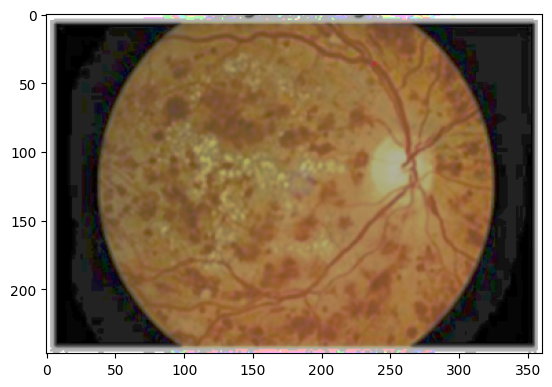

In [50]:
histEq(img2)

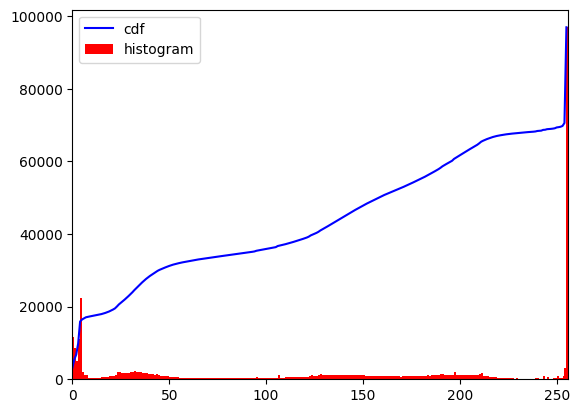

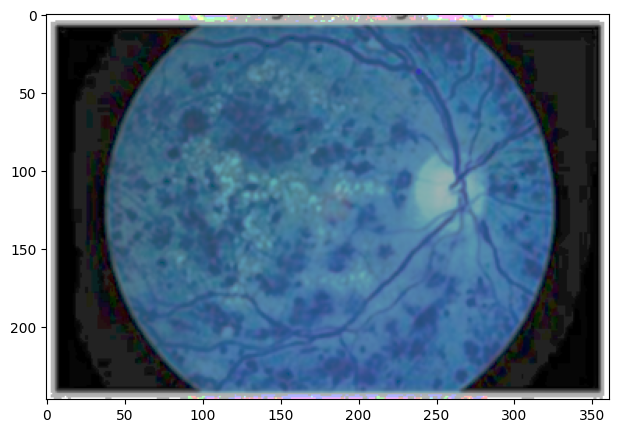

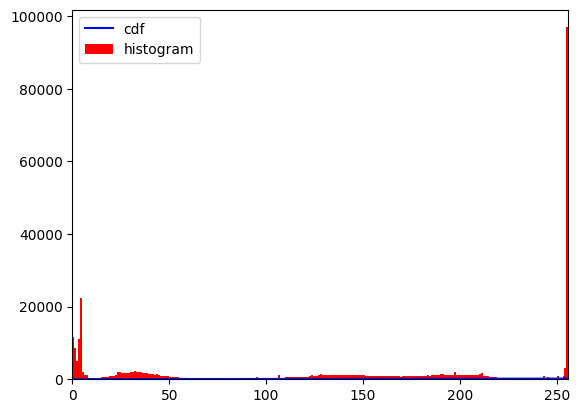

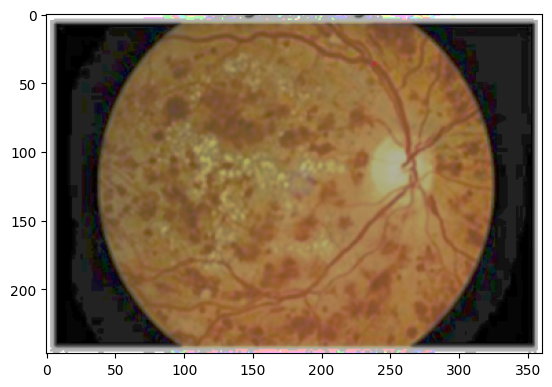

In [44]:
histEq(img2)

In [ ]:
#Convert the image file to a matrix
imgeWoman = np.array(imge)
imgeCameraman = np.array(imgeCameraman)

In [ ]:
sobImge = computeSobel(imge)
sobImgeWoman = computeSobel(imgeWoman)
sobImgeCameraman = computeSobel(imgeCameraman)

In [85]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def apply_histogram_equalization(image, clip_limit=40):
    """
    Applies histogram equalization to the given image with a clip limit.
    """

    # image = image[:, :, 1]  # Extract the green channel
    # Flatten the image and compute the histogram
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])

    # Compute cumulative distribution function (CDF)
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf[-1]  # Normalize

    # Clip the CDF to limit the enhancement
    cdf_clipped = np.clip(cdf_normalized, 0, clip_limit)
    
    # Compute new CDF after clipping
    cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
    cdf_clipped = cdf_clipped.astype(np.uint8)

    # Map the original image to the new CDF
    image_equalized = cdf_clipped[image]
    
    return image_equalized

def clahe(image, tile_size=(15, 15), clip_limit=40):
    """
    Applies CLAHE (Contrast Limited Adaptive Histogram Equalization) to the image.
    
    Arguments:
    - image: 2D array (grayscale image).
    - tile_size: Tuple (height, width) of the local regions.
    - clip_limit: Contrast clipping limit.
    
    Returns:
    - clahe_image: Image after applying CLAHE.
    """
    # Image dimensions
    img_height, img_width, x = image.shape

    # Prepare an empty array for the output
    clahe_image = np.zeros_like(image)

    # Loop through the image in tiles
    tile_height, tile_width = tile_size
    for i in range(0, img_height, tile_height):
        for j in range(0, img_width, tile_width):
            # Extract the current tile
            tile = image[i:i+tile_height, j:j+tile_width]

            # Apply histogram equalization to the tile
            equalized_tile = apply_histogram_equalization(tile, clip_limit)

            # Place the equalized tile back in the image
            clahe_image[i:i+tile_height, j:j+tile_width] = equalized_tile
    
    return clahe_image

C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\1223771128.py:22: RuntimeWarning: invalid value encountered in divide
  cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\1223771128.py:23: RuntimeWarning: invalid value encountered in cast
  cdf_clipped = cdf_clipped.astype(np.uint8)


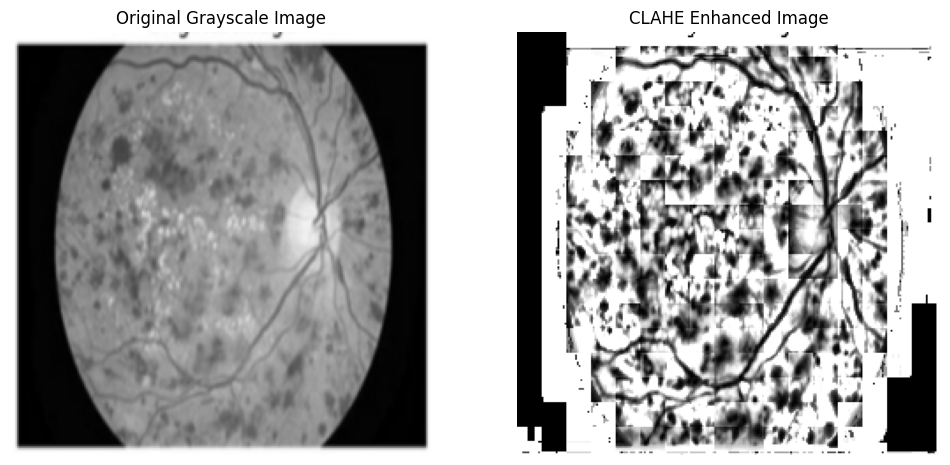

In [96]:
# Load an image (grayscale)
image_path = 'Screenshot 2024-11-20 184405.png'
image = Image.open(image_path).convert("L")

image = np.array(image)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
image = cv.resize(image, (240, 240))
image = np.array(image)
# Apply CLAHE
clahe_image = clahe(image, tile_size=(14, 14), clip_limit=25)

# Display the original and CLAHE enhanced images
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# CLAHE image
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(clahe_image, cv.COLOR_BGR2RGB))
plt.title('CLAHE Enhanced Image')
plt.axis('off')

plt.show()

# Optionally, save the output image
# output_image = Image.fromarray(clahe_image)
# output_image.save("clahe_output.jpg")


In [78]:
image.shape

(247, 361)

In [ ]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

In [70]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

def apply_histogram_equalization(image, clip_limit=40):
    """
    Applies histogram equalization to the given image with a clip limit.
    """
    # Flatten the image and compute the histogram
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])

    # Compute cumulative distribution function (CDF)
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf[-1]  # Normalize

    # Clip the CDF to limit the enhancement
    cdf_clipped = np.clip(cdf_normalized, 0, clip_limit)
    
    # Compute new CDF after clipping
    cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
    cdf_clipped = cdf_clipped.astype(np.uint8)

    # Map the original image to the new CDF
    image_equalized = cdf_clipped[image]
    
    return image_equalized

def bilinear_interpolation(image, new_height, new_width):
    """
    Perform bilinear interpolation to resize the image.
    """
    return zoom(image, (new_height / image.shape[0], new_width / image.shape[1]), order=1)

def clahe(image, tile_size=(15, 15), clip_limit=40):
    # Image dimensions
    img_height, img_width = image.shape

    # Prepare an empty array for the output
    clahe_image = np.zeros_like(image)

    # Loop through the image in tiles
    tile_height, tile_width = tile_size
    for i in range(0, img_height, tile_height):
        for j in range(0, img_width, tile_width):
            # Extract the current tile
            tile = image[i:i+tile_height, j:j+tile_width]

            # Apply histogram equalization to the tile
            equalized_tile = apply_histogram_equalization(tile, clip_limit)

            # Place the equalized tile back in the image
            clahe_image[i:i+tile_height, j:j+tile_width] = equalized_tile
    
    # Resize the final output using bilinear interpolation to smooth the tile boundaries
    clahe_image_resized = cv2.resize(clahe_image, (img_width, img_height), interpolation=cv2.INTER_LANCZOS4)
    # bilinear_interpolation(clahe_image, img_height, img_width)
    
    return clahe_image_resized

C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\749149407.py:21: RuntimeWarning: invalid value encountered in divide
  cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\749149407.py:22: RuntimeWarning: invalid value encountered in cast
  cdf_clipped = cdf_clipped.astype(np.uint8)


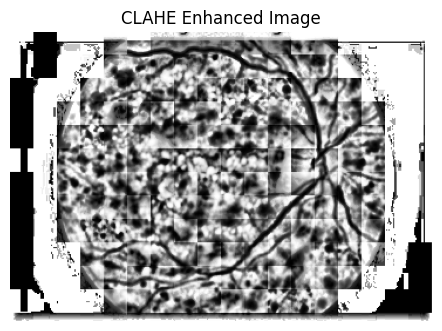

In [69]:
# Load an image (grayscale)
image_path = 'Screenshot 2024-11-20 184405.png'
image = Image.open(image_path).convert("L")
image = np.array(image)

# Apply CLAHE
clahe_image = clahe(image, tile_size=(20, 20), clip_limit=40)

# Display the original and CLAHE enhanced images
plt.figure(figsize=(12, 6))

# CLAHE image
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(clahe_image, cv.COLOR_BGR2RGB))
plt.title('CLAHE Enhanced Image')
plt.axis('off')

plt.show()

# Optionally, save the output image
# output_image = Image.fromarray(clahe_image)
# output_image.save("clahe_output.jpg")


C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\3642484455.py:21: RuntimeWarning: invalid value encountered in divide
  cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\3642484455.py:22: RuntimeWarning: invalid value encountered in cast
  cdf_clipped = cdf_clipped.astype(np.uint8)


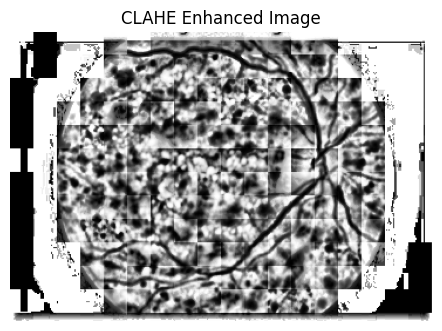

In [71]:
# Load an image (grayscale)
image_path = 'Screenshot 2024-11-20 184405.png'
image = Image.open(image_path).convert("L")
image = np.array(image)

# Apply CLAHE
clahe_image = clahe(image, tile_size=(20, 20), clip_limit=40)

# Display the original and CLAHE enhanced images
plt.figure(figsize=(12, 6))

# CLAHE image
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(clahe_image, cv.COLOR_BGR2RGB))
plt.title('CLAHE Enhanced Image')
plt.axis('off')

plt.show()

# Optionally, save the output image
# output_image = Image.fromarray(clahe_image)
# output_image.save("clahe_output.jpg")


In [72]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

def apply_histogram_equalization(image, clip_limit=40):
    """
    Applies histogram equalization to the given image with a clip limit.
    """
    # Flatten the image and compute the histogram
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])

    # Compute cumulative distribution function (CDF)
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf[-1]  # Normalize

    # Clip the CDF to limit the enhancement
    cdf_clipped = np.clip(cdf_normalized, 0, clip_limit)
    
    # Compute new CDF after clipping
    cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
    cdf_clipped = cdf_clipped.astype(np.uint8)

    # Map the original image to the new CDF
    image_equalized = cdf_clipped[image]
    
    return image_equalized

def apply_bilateral_filter(image, d=9, sigma_color=75, sigma_space=75):
    """
    Applies bilateral filtering to smooth the boundaries between tiles.
    
    Arguments:
    - image: Input image.
    - d: Diameter of pixel neighborhood.
    - sigma_color: Filter sigma in color space.
    - sigma_space: Filter sigma in coordinate space.
    
    Returns:
    - Filtered image.
    """
    return cv2.bilateralFilter(image, d, sigma_color, sigma_space)

def clahe(image, tile_size=(15, 15), clip_limit=40, apply_smoothing=True):
    """
    Applies CLAHE (Contrast Limited Adaptive Histogram Equalization) to the image.
    
    Arguments:
    - image: 2D array (grayscale image).
    - tile_size: Tuple (height, width) of the local regions.
    - clip_limit: Contrast clipping limit.
    - apply_smoothing: Boolean to apply smoothing to the image boundaries.
    
    Returns:
    - clahe_image: Image after applying CLAHE and optional smoothing.
    """
    # Image dimensions
    img_height, img_width = image.shape

    # Prepare an empty array for the output
    clahe_image = np.zeros_like(image)

    # Loop through the image in tiles
    tile_height, tile_width = tile_size
    for i in range(0, img_height, tile_height):
        for j in range(0, img_width, tile_width):
            # Extract the current tile
            tile = image[i:i+tile_height, j:j+tile_width]

            # Apply histogram equalization to the tile
            equalized_tile = apply_histogram_equalization(tile, clip_limit)

            # Place the equalized tile back in the image
            clahe_image[i:i+tile_height, j:j+tile_width] = equalized_tile
    
    # Apply bilateral filter to smooth the transitions between tiles
    if apply_smoothing:
        clahe_image = apply_bilateral_filter(clahe_image)

    # Resize the final output using OpenCV's bilinear interpolation for better performance
    clahe_image_resized = cv2.resize(clahe_image, (img_width, img_height), interpolation=cv2.INTER_LINEAR)
    
    return clahe_image_resized

C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\3657963522.py:21: RuntimeWarning: invalid value encountered in divide
  cdf_clipped = (cdf_clipped - cdf_clipped.min()) / (cdf_clipped.max() - cdf_clipped.min()) * 255
C:\Users\AbhinayP\AppData\Local\Temp\ipykernel_8788\3657963522.py:22: RuntimeWarning: invalid value encountered in cast
  cdf_clipped = cdf_clipped.astype(np.uint8)


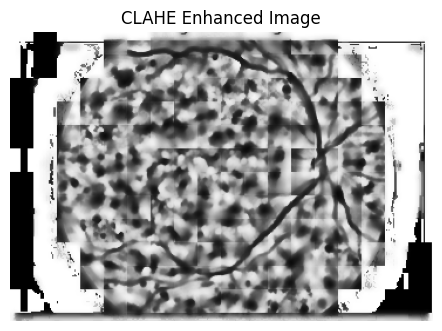

In [73]:
# Load an image (grayscale)
image_path = 'Screenshot 2024-11-20 184405.png'
image = Image.open(image_path).convert("L")
image = np.array(image)

# Apply CLAHE
clahe_image = clahe(image, tile_size=(20, 20), clip_limit=40)

# Display the original and CLAHE enhanced images
plt.figure(figsize=(12, 6))

# CLAHE image
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(clahe_image, cv.COLOR_BGR2RGB))
plt.title('CLAHE Enhanced Image')
plt.axis('off')

plt.show()

# Optionally, save the output image
# output_image = Image.fromarray(clahe_image)
# output_image.save("clahe_output.jpg")
